In [6]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Kraus, SuperOp
from qiskit.visualization import plot_histogram
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector,DensityMatrix,state_fidelity,partial_trace, Operator
from matplotlib import pyplot as plt
 
# Import from Qiskit Aer noise module
from qiskit_aer.noise import (
    NoiseModel,
    QuantumError,
    ReadoutError,
    depolarizing_error,
    pauli_error,
    thermal_relaxation_error,
)

Hamiltonian:

$H=h(X_1+X_2)+J Z_1 Z_2$

Trotter formula:

$e^{-iH t}=(e^{-i h X_1 \Delta t}e^{-i h X_2 \Delta t}e^{-i J Z_1 Z_2 \Delta t})^n,$

where $\Delta t=t/n$.

In [7]:
def tfim_circuit_with_noise_at_end(qc, n, m, J, h, t, p, epsilon):
    # Time increment for each Trotter step
    dt = t / p
    
    # Create a new quantum circuit
    
    # Define the depolarizing error
    depolarizing = depolarizing_error(epsilon, 1)
    two_qubit_depolarizing = depolarizing_error(epsilon, 2)
    
    for step in range(p):
        # Apply the ZZ coupling terms with noise
        for i in range(n,m):
            qc.rzz(2 * J * dt, i, i + 1)
        
        # Apply the transverse field terms with noise
        for i in range(n,m+1):
            qc.rx(2 * h * dt, i)
    qc.append(two_qubit_depolarizing, [n, m])
    
    return qc


In [36]:
def tfim_circuit_with_gate_noise(qc, n, m, J, h, t, p, epsilon):
    # Time increment for each Trotter step
    dt = t / p
    
    # Create a new quantum circuit
    
    # Define the depolarizing error
    depolarizing = depolarizing_error(epsilon, 1)
    two_qubit_depolarizing = depolarizing_error(epsilon, 2)
    
    for step in range(p):
        # Apply the ZZ coupling terms with noise
        for i in range(n,m):
            qc.rzz(2 * J * dt, i, i + 1)
            qc.append(two_qubit_depolarizing, [i, i+1])
        
        # Apply the transverse field terms with noise
        for i in range(n,m+1):
            qc.rx(2 * h * dt, i)
            qc.append(depolarizing, [i])
    
    return qc


In [37]:
# Example usage: generate simulation circuit
n = 2
m = 3
J = 1.0  # coupling strength
h = 1.0  # transverse field strength
t = 1.0  # total time for evolution
p = 10  # number of Trotter steps
epsilon = 0.1  # error rate for depolarizing channel

qc = QuantumCircuit(5)
circuit = tfim_circuit_with_noise_at_end(qc, n, m,J, h, t, p, epsilon)
print(circuit)

n = 2
m = 3
J = 1.0  # coupling strength
h = 1.0  # transverse field strength
t = 1.0  # total time for evolution
p = 10  # number of Trotter steps
epsilon = 0.1  # error rate for depolarizing channel

qc = QuantumCircuit(5)
circuit = tfim_circuit_with_gate_noise(qc, n, m,J, h, t, p, epsilon)
print(circuit)

                                                                              »
q_0: ─────────────────────────────────────────────────────────────────────────»
                                                                              »
q_1: ─────────────────────────────────────────────────────────────────────────»
               ┌─────────┐          ┌─────────┐          ┌─────────┐          »
q_2: ─■────────┤ Rx(0.2) ├─■────────┤ Rx(0.2) ├─■────────┤ Rx(0.2) ├─■────────»
      │ZZ(0.2) ├─────────┤ │ZZ(0.2) ├─────────┤ │ZZ(0.2) ├─────────┤ │ZZ(0.2) »
q_3: ─■────────┤ Rx(0.2) ├─■────────┤ Rx(0.2) ├─■────────┤ Rx(0.2) ├─■────────»
               └─────────┘          └─────────┘          └─────────┘          »
q_4: ─────────────────────────────────────────────────────────────────────────»
                                                                              »
«                                                                    »
«q_0: ───────────────────────────────────────────

In [69]:
# main SWAP circuit

def getPurifiedRho(epsilon,noise):

    # Create a Quantum Circuit acting on a quantum register of five qubits
    qc = QuantumCircuit(5)

    if noise ==0:
        qc=tfim_circuit_with_noise_at_end(qc, 1, 2, J, h, t, p, epsilon)
        qc=tfim_circuit_with_noise_at_end(qc, 3, 4, J, h, t, p, epsilon)

    else:
        qc=tfim_circuit_with_gate_noise(qc, 1, 2, J, h, t, p, epsilon)
        qc=tfim_circuit_with_gate_noise(qc, 3, 4, J, h, t, p, epsilon)
        
    # Apply the Hadamard gate to the first qubit
    qc.h(0)
    
    # Apply the first CSWAP gate controlled by q0, targeting q1 and q3
    qc.cswap(0, 1, 3)
    
    # Apply the second CSWAP gate controlled by q0, targeting q2 and q4
    qc.cswap(0, 2, 4)
    
    # Apply the second Hadamard gate to the first qubit
    qc.h(0)
    
    state = DensityMatrix(qc)

    # Create the 5-qubit projection operator using tensor products
   # Define the |0><0| projection matrix for a single qubit
    P0 = np.array([[1, 0],
                   [0, 0]])
    P1 = np.array([[0, 0],
                   [0, 1]])
    
    # Define the 2x2 identity matrix
    I = np.eye(2)
    projection_operator0 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P0))
    projection_operator1 = Operator(I).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(I)).tensor(Operator(P1))

    # Trace out all qubits except q0 to get the reduced density matrix for q0
    # output_rho _q0 = partial_trace(state, [1, 2, 3, 4])
    
    # # Extract probabilities from the reduced density matrix of q0
    # prob_0 = output_rho _q0.data[0, 0].real  # Probability of q0 being in |0>
    # prob_1 = output_rho _q0.data[1, 1].real  # Probability of q0 being in |1>

    #outcome0
    rho_outcome_0=projection_operator0@state@projection_operator0.adjoint()
    prob_0=np.trace(projection_operator0@state@projection_operator0)
    normalized_rho_outcome_0=rho_outcome_0/prob_0

    #outcome1
    rho_outcome_1=projection_operator1@state@projection_operator1.adjoint()
    prob_1=np.trace(projection_operator1@state@projection_operator1)
    normalized_rho_outcome_1=rho_outcome_1/prob_1

    # Trace out qubits q0, q3, and q4
    output_rho0 = partial_trace(DensityMatrix(normalized_rho_outcome_0), [0, 1, 2])
    output_rho1 = partial_trace(DensityMatrix(normalized_rho_outcome_1), [0, 1, 2])

    purified_rho=prob_0*output_rho0  + prob_1*output_rho1 #for both outcomes, trace out one reg, therefore the overall state should be as if the purification is not done

    return purified_rho


In [63]:
#Input state without purification, used for benchmarking
def getInputRho(epsilon,gate_noise=0):

    # Create a Quantum Circuit acting on a quantum register of 2 qubits
    qc = QuantumCircuit(2)

    if gate_noise==0:
        qc=tfim_circuit_with_noise_at_end(qc, 0, 1, J, h, t, p, epsilon)
    else:
        qc=tfim_circuit_with_gate_noise(qc, 0, 1, J, h, t, p, epsilon)
        
    state = DensityMatrix(qc)

    return state
    

In [64]:
pure_state = getInputRho(0)
#Run sims and compare the two different rhos
list_of_epsilon=[i * 0.01 for i in range(101)]
list_of_purified_fidelity=[]
list_of_fidelity=[]
for i in list_of_epsilon:
    list_of_purified_fidelity.append(state_fidelity(getPurifiedRho(i,1), pure_state))
    list_of_fidelity.append(state_fidelity(getInputRho(i,1), pure_state))

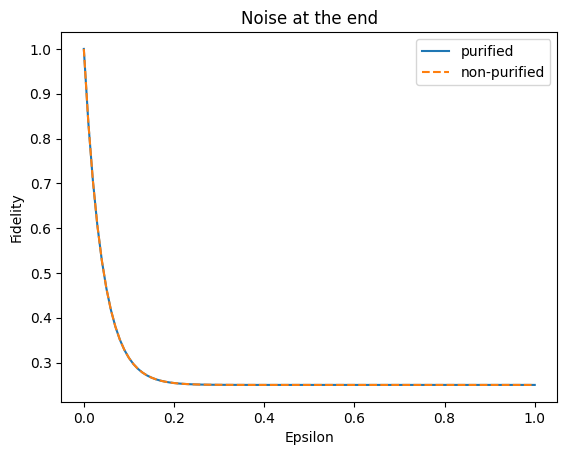

In [65]:
plt.plot(list_of_epsilon,list_of_purified_fidelity,label='purified')
plt.plot(list_of_epsilon,list_of_fidelity,label='non-purified', linestyle='dashed')
plt.title("Noise at the end")
plt.xlabel("Epsilon")
plt.ylabel("Fidelity")
plt.legend()

In [56]:
pure_state = getInputRho(0)
#Run sims and compare the two different rhos
list_of_epsilon=[i * 0.01 for i in range(101)]
list_of_purified_fidelity=[]
list_of_fidelity=[]
for i in list_of_epsilon:
    list_of_purified_fidelity.append(state_fidelity(getPurifiedRho(i,0), pure_state))
    list_of_fidelity.append(state_fidelity(getInputRho(i,0), pure_state))

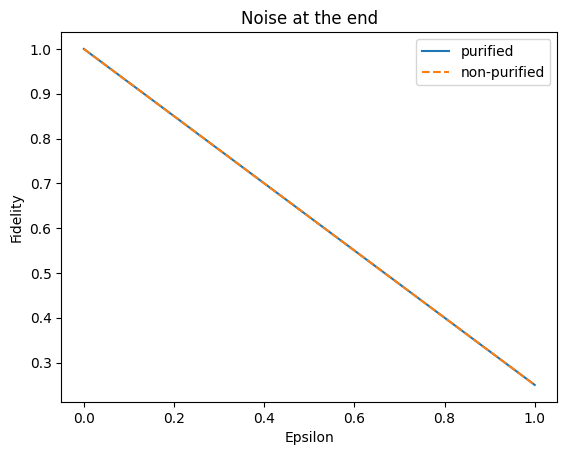

In [58]:
plt.plot(list_of_epsilon,list_of_purified_fidelity,label='purified')
plt.plot(list_of_epsilon,list_of_fidelity,label='non-purified', linestyle='dashed')
plt.title("Noise at the end")
plt.xlabel("Epsilon")
plt.ylabel("Fidelity")
plt.legend()

In [59]:
list_of_epsilon=[i * 0.001 for i in range(101)]
list_of_purified_fidelity=[]
list_of_fidelity=[]
for i in list_of_epsilon:
    list_of_purified_fidelity.append(state_fidelity(purified_rho_with(i,1), pure_state))
    list_of_fidelity.append(state_fidelity(rho_with(i,1), pure_state))

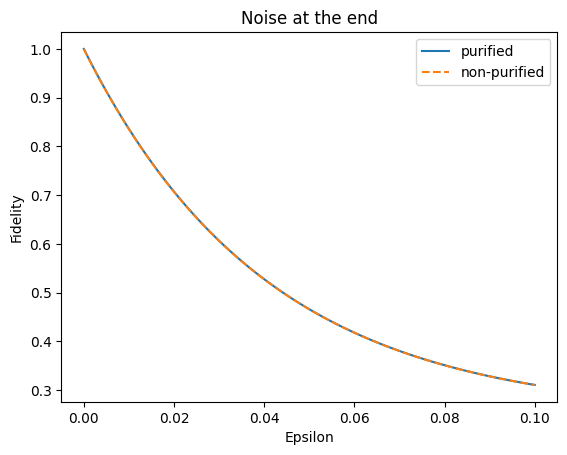

In [60]:
plt.plot(list_of_epsilon,list_of_purified_fidelity,label='purified')
plt.plot(list_of_epsilon,list_of_fidelity,label='non-purified', linestyle='dashed')
plt.title("Noise at the end")
plt.xlabel("Epsilon")
plt.ylabel("Fidelity")
plt.legend()